# Part 3 — FinBERT Sentiment Analysis

See `README.md` for project context and motivation.

This notebook analyses **sentence-level** FinBERT sentiment on the **250 geoeconomically-flagged transcripts** identified in Part 2. Rather than scoring entire documents, inference was run only on sentences that match a georisk pattern, using a ±1 sentence context window. This gives a more targeted view of how executives and analysts talk about geoeconomic risks specifically.

Results are merged with LDA topic assignments to answer:

- What is the overall sentiment tone of georisk-related speech?
- Which LDA topics discuss geoeconomic risks most negatively?
- Does sentiment in georisk sentences shift across reporting quarters?
- Do executives frame georisk differently from analysts?
- Which risk category (trade, sanctions, embargo, geopolitical) carries the most negative tone?

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
})

print('Setup complete.')

Setup complete.


## 2. Run inference (via `03_finbert_inference.py`)

Inference is handled by the companion script **`03_finbert_inference.py`**,
which identifies georisk sentences in the 250 flagged transcripts, scores each
with a ±1 sentence context window, and saves incremental checkpoints so a
long run can be safely interrupted and resumed.

```bash
# Full run on all 250 flagged transcripts
python 03_finbert_inference.py

# Test on first 10 transcripts
python 03_finbert_inference.py --limit 10

# Resume an interrupted run
python 03_finbert_inference.py --resume
```

Once the script has finished, `data/finbert_sentiment.csv` is available and
the cells below will load it automatically.

In [2]:
CACHE_PATH = Path('data/finbert_sentiment.csv')

if not CACHE_PATH.exists():
    raise FileNotFoundError(
        f'{CACHE_PATH} not found.\n'
        'Run the inference script first:\n'
        '  python 03_finbert_inference.py\n'
        'or for a quick test:\n'
        '  python 03_finbert_inference.py --limit 10'
    )

sent_df = pd.read_csv(CACHE_PATH)
print(f'Loaded {CACHE_PATH}: {len(sent_df):,} georisk sentences, {len(sent_df.columns)} columns')
print(f'Transcripts covered : {sent_df["url"].nunique():,}')
print(f'Speaker type counts : {sent_df["speaker_type"].value_counts().to_dict()}')
sent_df.head(3)

Loaded data/finbert_sentiment.csv: 312 georisk sentences, 13 columns
Transcripts covered : 231
Speaker type counts : {'exec': 253, 'analyst': 59}


,url,speaker_type,sent_idx,sentence_text,context_text,trade_risk,sanctions_risk,embargo_risk,geopolitical_risk,p_positive,p_negative,p_neutral,sentiment
0,https://www.investing.com/news/transcripts/apo...,exec,104,"Like, the relationships with banks and the par...","We’re not saying it. Like, the relationships w...",True,False,False,False,0.153628,0.012282,0.834090,neutral
1,https://www.investing.com/news/transcripts/are...,exec,98,The narrative that people wanna talk about is ...,So this is another example of a one-sided narr...,False,False,False,True,0.044887,0.180911,0.774203,neutral
2,https://www.investing.com/news/transcripts/ban...,exec,53,"The other major thing, and I think this is imp...",I think the good news is they’re taking the ti...,True,False,False,False,0.129959,0.024063,0.845977,neutral


## 4. Merge with metadata and LDA topics

In [3]:
# Transcript metadata
meta = pd.read_csv('data/corpus_documents.csv',
                   usecols=['url', 'company_name', 'ticker',
                            'reporting_period', 'event_type'])

# LDA dominant topic
gamma = pd.read_csv('data/doc_topic_distributions.csv',
                    usecols=['url', 'dominant_topic', 'dominant_label'])

df = (
    sent_df
    .merge(meta,  on='url', how='left')
    .merge(gamma, on='url', how='left')
)

df['net_sentiment'] = df['p_positive'] - df['p_negative']

# Q1 2025 has no transcripts in this corpus; start from Q2 2025
PERIOD_ORDER = ['Q2 2025', 'Q3 2025', 'Q4 2025',
                'Q1 2026', 'Q2 2026', 'Q3 2026', 'Q4 2026']
df['reporting_period'] = pd.Categorical(
    df['reporting_period'], categories=PERIOD_ORDER, ordered=True
)

print(f'Merged: {len(df):,} georisk sentences across {df["url"].nunique():,} transcripts')
print(df[['speaker_type', 'sentiment', 'net_sentiment',
          'trade_risk', 'geopolitical_risk']].describe(include='all').T)

Merged: 312 georisk sentences across 231 transcripts
                   count unique      top freq      mean       std       min  \
speaker_type         312      2     exec  253       NaN       NaN       NaN   
sentiment            312      3  neutral  167       NaN       NaN       NaN   
net_sentiment      312.0    NaN      NaN  NaN  0.197167  0.464072 -0.967524   
trade_risk           312      2     True  265       NaN       NaN       NaN   
geopolitical_risk    312      2    False  256       NaN       NaN       NaN   

                        25%       50%      75%       max  
speaker_type            NaN       NaN      NaN       NaN  
sentiment               NaN       NaN      NaN       NaN  
net_sentiment     -0.000574  0.110245  0.52826  0.940428  
trade_risk              NaN       NaN      NaN       NaN  
geopolitical_risk       NaN       NaN      NaN       NaN  


## 5. Visualisations

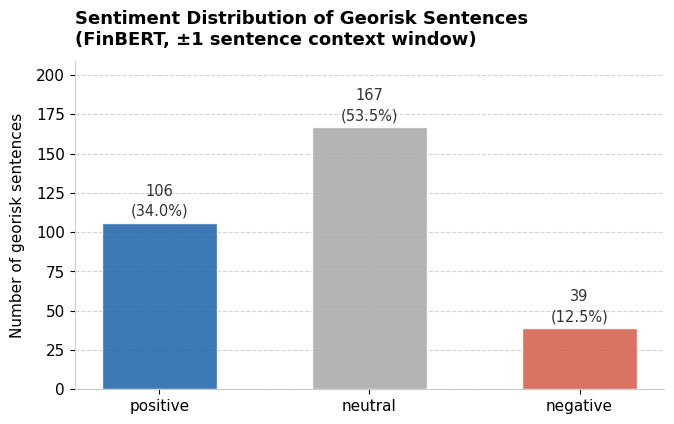

Saved figures/14_finbert_sentiment_dist.png


In [4]:
# ── Fig 1: Sentiment distribution of georisk sentences ─────────────────────

SENT_COLORS = {'positive': '#2166AC', 'neutral': '#AAAAAA', 'negative': '#D6604D'}

counts = df['sentiment'].value_counts().reindex(['positive', 'neutral', 'negative'])
total  = counts.sum()

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(counts.index, counts.values,
              color=[SENT_COLORS[s] for s in counts.index],
              alpha=0.88, edgecolor='white', linewidth=1.0, width=0.55)

for bar, (label, count) in zip(bars, counts.items()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + total * 0.008,
            f'{count:,}\n({100*count/total:.1f}%)',
            ha='center', va='bottom', fontsize=10.5, color='#333333',
            linespacing=1.4)

ax.set_ylabel('Number of georisk sentences', fontsize=11, labelpad=8)
ax.set_title('Sentiment Distribution of Georisk Sentences\n'
             '(FinBERT, \u00b11 sentence context window)',
             fontsize=13, fontweight='bold', pad=12, loc='left')
ax.set_ylim(0, counts.max() * 1.25)
ax.yaxis.grid(True, linestyle='--', alpha=0.35, color='grey', zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#cccccc')
plt.tight_layout(pad=1.5)
plt.savefig('figures/14_finbert_sentiment_dist.png', dpi=160,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Saved figures/14_finbert_sentiment_dist.png')

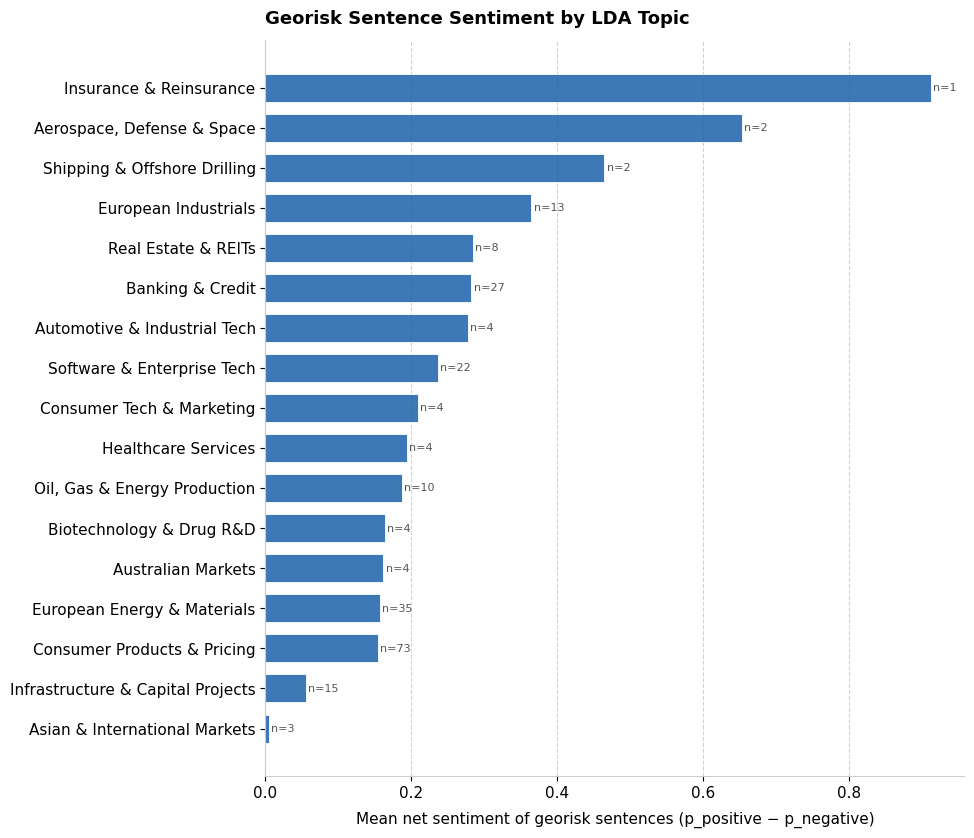

Saved figures/15_finbert_by_topic.png


In [5]:
# ── Fig 2: Georisk sentence sentiment by LDA topic ─────────────────────────
# Aggregate to transcript level first to avoid high-frequency transcripts
# dominating the topic averages.

transcript_sent = (
    df.dropna(subset=['dominant_label', 'net_sentiment'])
    .groupby(['url', 'dominant_label'])['net_sentiment']
    .mean()
    .reset_index()
)
topic_sent = (
    transcript_sent
    .groupby('dominant_label')
    .agg(mean_net=('net_sentiment', 'mean'),
         n=('net_sentiment', 'count'))
    .sort_values('mean_net')
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, max(5, len(topic_sent) * 0.42 + 1.5)))
colors = ['#D6604D' if v < 0 else '#2166AC' for v in topic_sent['mean_net']]
bars   = ax.barh(topic_sent['dominant_label'], topic_sent['mean_net'],
                 color=colors, alpha=0.88, edgecolor='white',
                 linewidth=0.7, height=0.7)

for bar, (_, row) in zip(bars, topic_sent.iterrows()):
    x_pos = row['mean_net'] + (0.003 if row['mean_net'] >= 0 else -0.003)
    ha    = 'left' if row['mean_net'] >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f"n={row['n']:,}", va='center', ha=ha,
            fontsize=8, color='#555555')

ax.axvline(0, color='#888888', linewidth=1.2, linestyle='--')
ax.set_xlabel('Mean net sentiment of georisk sentences (p_positive \u2212 p_negative)',
              fontsize=11, labelpad=8)
ax.set_title('Georisk Sentence Sentiment by LDA Topic',
             fontsize=13, fontweight='bold', pad=12, loc='left')
ax.xaxis.grid(True, linestyle='--', alpha=0.35, color='grey', zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#cccccc')
plt.tight_layout(pad=1.5)
plt.savefig('figures/15_finbert_by_topic.png', dpi=160,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Saved figures/15_finbert_by_topic.png')

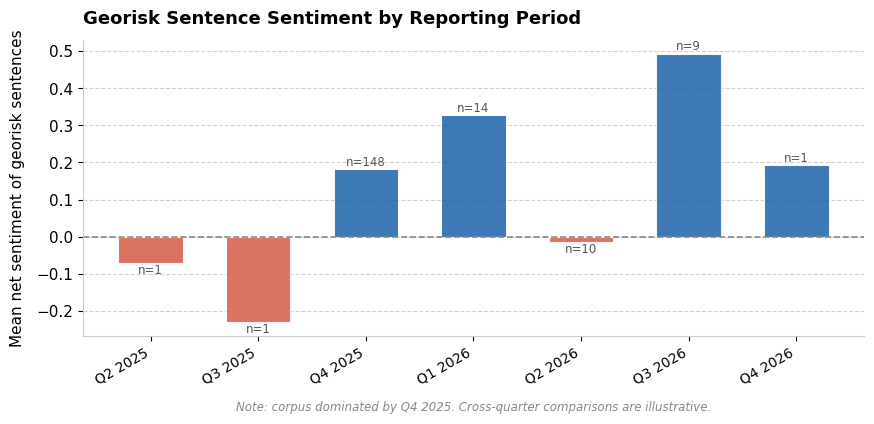

Saved figures/16_finbert_by_period.png


In [6]:
# ── Fig 3: Georisk sentence sentiment by reporting period ──────────────────

transcript_sent = (
    df.dropna(subset=['reporting_period', 'net_sentiment'])
    .groupby(['url', 'reporting_period'], observed=True)['net_sentiment']
    .mean()
    .reset_index()
)
period_sent = (
    transcript_sent
    .groupby('reporting_period', observed=True)
    .agg(mean_net=('net_sentiment', 'mean'),
         n=('net_sentiment', 'count'))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(period_sent))
colors = ['#D6604D' if v < 0 else '#2166AC' for v in period_sent['mean_net']]
bars   = ax.bar(x, period_sent['mean_net'], color=colors, alpha=0.88,
                edgecolor='white', linewidth=0.8, width=0.60)

for xi, (_, row) in enumerate(period_sent.iterrows()):
    y_off = 0.002 if row['mean_net'] >= 0 else -0.002
    va    = 'bottom' if row['mean_net'] >= 0 else 'top'
    ax.text(xi, row['mean_net'] + y_off,
            f"n={row['n']:,}", ha='center', va=va,
            fontsize=8.5, color='#555555')

ax.axhline(0, color='#888888', linewidth=1.2, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(period_sent['reporting_period'].astype(str),
                   rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Mean net sentiment of georisk sentences', fontsize=11, labelpad=8)
ax.set_title('Georisk Sentence Sentiment by Reporting Period',
             fontsize=13, fontweight='bold', pad=12, loc='left')
ax.set_xlabel(
    'Note: corpus dominated by Q4 2025. Cross-quarter comparisons are illustrative.',
    fontsize=8.5, color='#888888', labelpad=10, style='italic'
)
ax.yaxis.grid(True, linestyle='--', alpha=0.35, color='grey', zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#cccccc')
plt.tight_layout(pad=1.5)
plt.savefig('figures/16_finbert_by_period.png', dpi=160,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Saved figures/16_finbert_by_period.png')

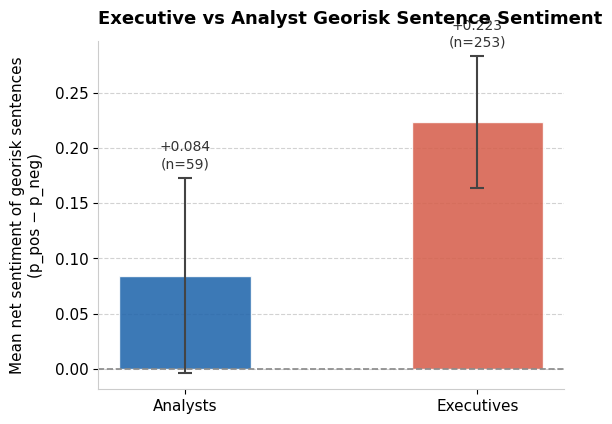

Saved figures/17_finbert_exec_vs_analyst.png


In [7]:
# ── Fig 4: Executive vs analyst georisk sentence sentiment ─────────────────

role_agg = (
    df.dropna(subset=['net_sentiment'])
    .groupby('speaker_type')
    .agg(mean_net=('net_sentiment', 'mean'),
         std=('net_sentiment', 'std'),
         n=('net_sentiment', 'count'))
    .reset_index()
)
role_agg['se']    = role_agg['std'] / np.sqrt(role_agg['n'])
role_agg['label'] = role_agg['speaker_type'].map(
    {'exec': 'Executives', 'analyst': 'Analysts'})

fig, ax = plt.subplots(figsize=(6, 4.5))
ROLE_COLORS = ['#2166AC', '#D6604D']
bars = ax.bar(role_agg['label'], role_agg['mean_net'],
              color=ROLE_COLORS[:len(role_agg)], alpha=0.88, edgecolor='white',
              linewidth=1.0, width=0.45,
              yerr=role_agg['se'] * 1.96, capsize=5,
              error_kw={'elinewidth': 1.5, 'ecolor': '#444444', 'capthick': 1.5})

for bar, (_, row) in zip(bars, role_agg.iterrows()):
    y_off = 0.002 if row['mean_net'] >= 0 else -0.002
    ax.text(bar.get_x() + bar.get_width() / 2,
            row['mean_net'] + row['se'] * 1.96 + abs(y_off) * 3,
            f"{row['mean_net']:+.3f}\n(n={row['n']:,})",
            ha='center', va='bottom', fontsize=10, color='#333333',
            linespacing=1.3)

ax.axhline(0, color='#888888', linewidth=1.2, linestyle='--')
ax.set_ylabel('Mean net sentiment of georisk sentences\n(p_pos \u2212 p_neg)',
              fontsize=11, labelpad=8)
ax.set_title('Executive vs Analyst Georisk Sentence Sentiment',
             fontsize=13, fontweight='bold', pad=12, loc='left')
ax.yaxis.grid(True, linestyle='--', alpha=0.35, color='grey', zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#cccccc')
plt.tight_layout(pad=1.5)
plt.savefig('figures/17_finbert_exec_vs_analyst.png', dpi=160,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Saved figures/17_finbert_exec_vs_analyst.png')

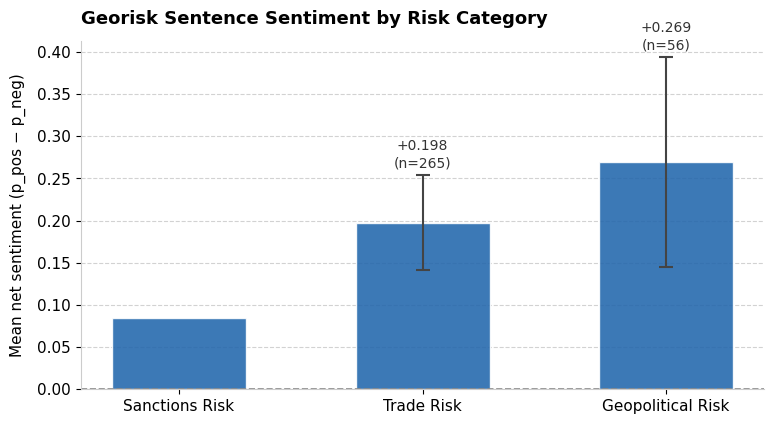

Saved figures/18_finbert_georisk_vs_not.png


In [8]:
# ── Fig 5: Georisk sentence sentiment by risk category ─────────────────────
# Each sentence may match multiple categories; categories are not mutually
# exclusive. n = number of sentences matching that category.

CAT_LABELS = {
    'trade_risk':        'Trade Risk',
    'sanctions_risk':    'Sanctions Risk',
    'embargo_risk':      'Embargo Risk',
    'geopolitical_risk': 'Geopolitical Risk',
}

cat_rows = []
for col, label in CAT_LABELS.items():
    sub = df.loc[df[col] == True, 'net_sentiment'].dropna()
    if len(sub) == 0:
        continue
    cat_rows.append({
        'label':    label,
        'mean_net': sub.mean(),
        'std':      sub.std(),
        'n':        len(sub),
        'se':       sub.std() / np.sqrt(len(sub)),
    })
cat_df = pd.DataFrame(cat_rows).sort_values('mean_net').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ['#D6604D' if v < 0 else '#2166AC' for v in cat_df['mean_net']]
bars = ax.bar(cat_df['label'], cat_df['mean_net'],
              color=colors, alpha=0.88, edgecolor='white',
              linewidth=1.0, width=0.55,
              yerr=cat_df['se'] * 1.96, capsize=5,
              error_kw={'elinewidth': 1.5, 'ecolor': '#444444', 'capthick': 1.5})

for bar, (_, row) in zip(bars, cat_df.iterrows()):
    y_off = 0.002 if row['mean_net'] >= 0 else -0.002
    ax.text(bar.get_x() + bar.get_width() / 2,
            row['mean_net'] + row['se'] * 1.96 + abs(y_off) * 3,
            f"{row['mean_net']:+.3f}\n(n={row['n']:,})",
            ha='center', va='bottom', fontsize=10, color='#333333',
            linespacing=1.3)

ax.axhline(0, color='#888888', linewidth=1.2, linestyle='--')
ax.set_ylabel('Mean net sentiment (p_pos \u2212 p_neg)', fontsize=11, labelpad=8)
ax.set_title('Georisk Sentence Sentiment by Risk Category',
             fontsize=13, fontweight='bold', pad=12, loc='left')
ax.yaxis.grid(True, linestyle='--', alpha=0.35, color='grey', zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#cccccc')
plt.tight_layout(pad=1.5)
plt.savefig('figures/18_finbert_georisk_vs_not.png', dpi=160,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Saved figures/18_finbert_georisk_vs_not.png')

In [9]:
# Export merged results
out_cols = [
    'url', 'company_name', 'ticker', 'reporting_period', 'event_type',
    'dominant_label', 'speaker_type', 'sent_idx', 'sentence_text', 'context_text',
    'trade_risk', 'sanctions_risk', 'embargo_risk', 'geopolitical_risk',
    'p_positive', 'p_negative', 'p_neutral', 'sentiment', 'net_sentiment',
]
out_cols = [c for c in out_cols if c in df.columns]
df[out_cols].to_csv('data/finbert_results.csv', index=False)
print(f'Saved data/finbert_results.csv  ({len(df):,} georisk sentences)')

Saved data/finbert_results.csv  (312 georisk sentences)


## Summary

| File | Description |
|---|---|
| `data/finbert_sentiment.csv` | Raw FinBERT scores — one row per georisk sentence (with context window) |
| `data/finbert_results.csv` | Merged: scores + LDA topics + transcript metadata |
| `figures/14_finbert_sentiment_dist.png` | Sentiment distribution of georisk sentences |
| `figures/15_finbert_by_topic.png` | Mean georisk sentence sentiment by LDA topic |
| `figures/16_finbert_by_period.png` | Mean georisk sentence sentiment by reporting quarter |
| `figures/17_finbert_exec_vs_analyst.png` | Executive vs analyst georisk sentence sentiment |
| `figures/18_finbert_georisk_vs_not.png` | Georisk sentence sentiment by risk category |